## Part C – Anomaly Detection

Step 1: Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Data

In [2]:
behaviour = pd.read_csv(
    "txn_behaviour.csv"
)

print(behaviour.shape)

behaviour.head()

(265, 6)


,txn_id,applicant_id,txn_hour,is_new_device,txn_amount_inr,channel
0,BTXN5000,APP1126,15,0,199,P2P
1,BTXN5001,APP1167,22,0,499,P2P
2,BTXN5002,APP1079,18,0,1999,P2P
3,BTXN5003,APP1293,18,1,999,P2M
4,BTXN5004,APP1332,12,0,199,P2P


Step 3: Select Behavioural Features

In [3]:
features = [
    "txn_hour",
    "is_new_device",
    "txn_amount_inr"
]

X = behaviour[features]

Step 4: Standardize Data

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Step 5: Define Contamination Rate

In [5]:
contamination_rate = 15 / 265

print(contamination_rate)

0.05660377358490566


Step 6: Train Isolation Forest

In [6]:
iso = IsolationForest(
    random_state=42,
    contamination=15/265
)

iso.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05660377358490566
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


Step 7: Predict Anomalies

In [7]:
behaviour["anomaly_flag"] = (
    iso.predict(X_scaled)
)

behaviour["prediction"] = (
    behaviour["anomaly_flag"]
    .map({
        1: "Normal",
       -1: "Anomaly"
    })
)

Step 8: Count Detected Anomalies

In [8]:
detected_anomalies = (
    behaviour["anomaly_flag"] == -1
).sum()

print(
    "Detected anomalies:",
    detected_anomalies
)

Detected anomalies: 15


## simple recall check against your own injected ground truth

In [9]:
seeded = behaviour[
    behaviour["txn_id"]
    .str.startswith("BTXNA")
]
len(seeded)

15

Count Correctly Flagged Seeded Anomalies

In [10]:
true_detected = seeded[
    seeded["anomaly_flag"] == -1
]

detected_count = len(
    true_detected
)

print(
    f"Seeded anomalies detected: "
    f"{detected_count}/15"
)

Seeded anomalies detected: 11/15


Recall Calculation

In [11]:
recall = (
    detected_count / 15
) * 100

print(
    f"Recall: {recall:.2f}%"
)

Recall: 73.33%


Step 9: Create Required Image

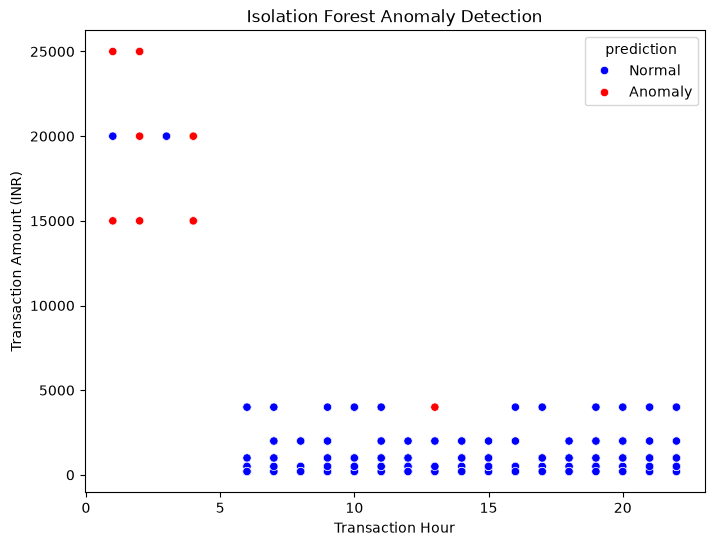

In [12]:
plt.figure(
    figsize=(8,6)
)

sns.scatterplot(
    data=behaviour,
    x="txn_hour",
    y="txn_amount_inr",
    hue="prediction",
    palette={
        "Normal":"blue",
        "Anomaly":"red"
    }
)

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.xlabel(
    "Transaction Hour"
)

plt.ylabel(
    "Transaction Amount (INR)"
)

plt.savefig(
    "anomaly_scatter.png",
    bbox_inches="tight"
)

plt.show()

## Optional Part – K-Means Segmentation (Ungraded)

Step 1: Imports

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

Step 2: Load Applicant Data

In [14]:
applicants = pd.read_csv(
    "credit_applicants.csv"
)

print(applicants.shape)

applicants.head()

(400, 10)


,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0


Step 3: Create Thin-File Indicator

In [15]:
applicants["is_thin_file"] = (
    applicants["credit_bureau_score"]
    .isna()
    .astype(int)
)

Step 4: Impute Missing Bureau Scores

In [16]:
bureau_median = (
    applicants["credit_bureau_score"]
    .median()
)

applicants["credit_bureau_score"] = (
    applicants["credit_bureau_score"]
    .fillna(bureau_median)
)

Step 5: One-Hot Encode Employment Type

In [17]:
applicants_encoded = pd.get_dummies(
    applicants,
    columns=["employment_type"],
    drop_first=True
)

Step 6: Select Clustering Features

In [18]:
cluster_features = applicants_encoded.drop(
    columns=[
        "applicant_id",
        "default"
    ]
)

Step 7: Standardize Features

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_features
)

Step 8: Determine Optimal K

In [20]:
scores = []

k_values = range(2, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = model.fit_predict(
        X_scaled
    )

    score = calinski_harabasz_score(
        X_scaled,
        cluster_labels
    )

    scores.append(score)

    print(
        f"K={k}: CH Score={score:.2f}"
    )

K=2: CH Score=73.26
K=3: CH Score=60.41
K=4: CH Score=53.61
K=5: CH Score=46.74
K=6: CH Score=42.47
K=7: CH Score=39.56
K=8: CH Score=36.25


Step 9: Visualize K Selection

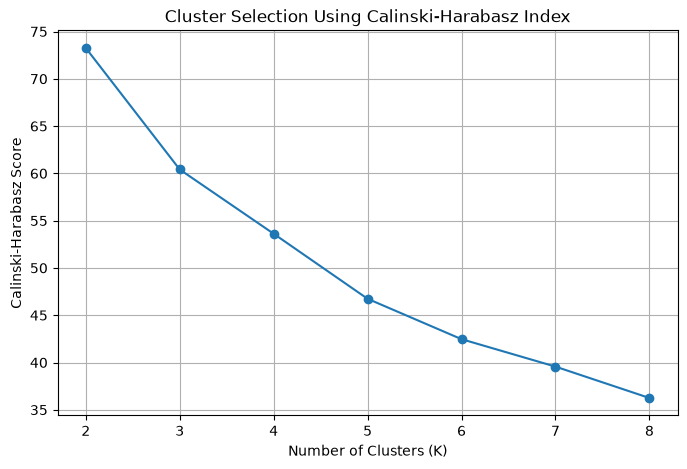

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")

plt.title(
    "Cluster Selection Using Calinski-Harabasz Index"
)

plt.grid(True)

plt.show()

Step 10: Choose Best K

In [22]:
best_k = k_values[
    np.argmax(scores)
]

print(
    f"Best K = {best_k}"
)

Best K = 2


Step 11: Fit Final K-Means Model

In [23]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

applicants["cluster"] = (
    kmeans.fit_predict(X_scaled)
)

Step 12: Profile Clusters

In [24]:
cluster_summary = (
    applicants
    .groupby("cluster")
    .agg(
        applicants=("default","count"),
        avg_income=(
            "monthly_income_inr",
            "mean"
        ),
        avg_bureau_score=(
            "credit_bureau_score",
            "mean"
        ),
        avg_utilization=(
            "credit_utilization_ratio",
            "mean"
        ),
        default_rate=(
            "default",
            "mean"
        )
    )
)

Step 13: Identify High-Risk Clusters

In [25]:
highest_default_cluster = (
    cluster_summary[
        "default_rate"
    ].idxmax()
)

highest_default_rate = (
    cluster_summary.loc[
        highest_default_cluster,
        "default_rate"
    ]
)

print(
    f"Cluster {highest_default_cluster} "
    f"has the highest default rate "
    f"({highest_default_rate:.2f}%)"
)

Cluster 1 has the highest default rate (0.23%)


Step 14: Visualize Cluster Default Rates

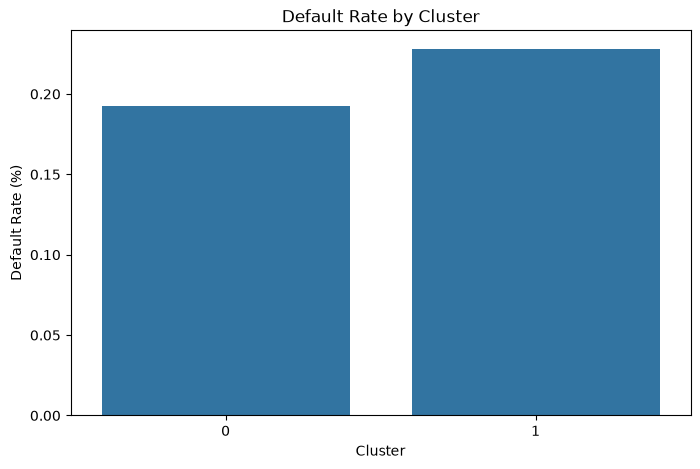

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["default_rate"]
)

plt.xlabel("Cluster")
plt.ylabel("Default Rate (%)")

plt.title(
    "Default Rate by Cluster"
)

plt.show()

Step 15: 2-D Cluster Visualization

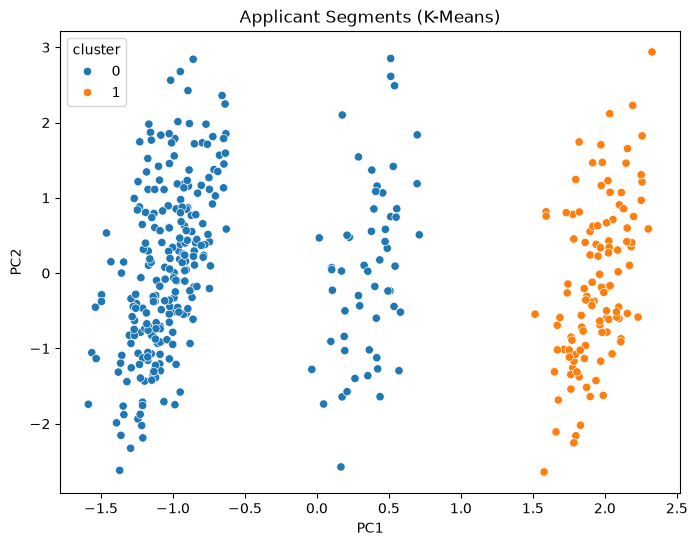

In [27]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    X_scaled
)

cluster_plot = pd.DataFrame({
    "PC1": pca_data[:,0],
    "PC2": pca_data[:,1],
    "cluster": applicants["cluster"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cluster_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10"
)

plt.title(
    "Applicant Segments (K-Means)"
)

plt.show()